In [1]:
"""
Friedman + Nemenyi (post-hoc) for paired model comparisons across blocks.

This script:
1) Defines the TA-CV and LOPO result matrices you provided.
2) Pools them (TA-CV + LOPO) into one block set (N blocks x k methods).
3) Runs the Friedman test across methods.
4) Computes per-block ranks (1 = best, higher score = better), average ranks, and the Nemenyi
   critical difference (CD) at alpha=0.05.
5) Computes all pairwise Nemenyi p-values (Studentized range distribution).
6) Prints complete results + extracts the specific comparisons: ours vs Mantis / Gen HC / EDA HC.

Dependencies:
- numpy
- scipy
- pandas (optional but recommended for nice tables)
- statsmodels (for qsturng/psturng)

If you don't have statsmodels:
  pip install statsmodels
"""

from __future__ import annotations

import numpy as np
from scipy.stats import friedmanchisquare, rankdata

try:
    import pandas as pd
except ImportError:
    pd = None

from statsmodels.stats.libqsturng import qsturng, psturng


def friedman_nemenyi(
    data: np.ndarray,
    method_names: list[str],
    *,
    alpha: float = 0.05,
    higher_is_better: bool = True,
) -> dict:
    """
    Run Friedman test + Nemenyi post-hoc on a (N_blocks, k_methods) matrix.

    Args:
        data: Array of shape (N, k) with one row per block and one column per method.
        method_names: List of length k with method names (column order of `data`).
        alpha: Significance level for the Nemenyi critical difference.
        higher_is_better: If True, larger values are better; ranks computed accordingly.

    Returns:
        Dictionary containing Friedman stats, per-block ranks, average ranks, CD, and pairwise table.
    """
    if data.ndim != 2:
        raise ValueError("data must be 2D (N_blocks, k_methods).")
    N, k = data.shape
    if len(method_names) != k:
        raise ValueError("method_names length must match number of columns in data.")

    # Friedman test expects one array per method (paired across blocks)
    fried_stat, fried_p = friedmanchisquare(*[data[:, j] for j in range(k)])

    # Compute ranks per block: rank 1 = best
    ranks = np.zeros_like(data, dtype=float)
    for i in range(N):
        row = data[i]
        if higher_is_better:
            ranks[i] = rankdata(-row, method="average")  # invert so higher => smaller rank
        else:
            ranks[i] = rankdata(row, method="average")

    avg_ranks = ranks.mean(axis=0)

    # Nemenyi CD
    # Use df = infinity approximation for Studentized range
    q_alpha = qsturng(1 - alpha, k, np.inf)
    se = np.sqrt(k * (k + 1) / (6 * N))
    cd = q_alpha * se

    # Pairwise Nemenyi p-values
    pair_rows = []
    for a in range(k):
        for b in range(a + 1, k):
            diff = abs(avg_ranks[a] - avg_ranks[b])
            q = diff / se
            # psturng returns CDF; for Nemenyi, use upper-tail: p = 1 - CDF
            # statsmodels' psturng returns the CDF of the studentized range distribution.
            p_val = float(1.0 - psturng(q, k, np.inf))
            pair_rows.append(
                {
                    "A": method_names[a],
                    "B": method_names[b],
                    "avg_rank_A": avg_ranks[a],
                    "avg_rank_B": avg_ranks[b],
                    "abs_rank_diff": diff,
                    "q_stat": q,
                    "p_nemenyi": p_val,
                    "significant_cd": diff > cd,
                }
            )

    if pd is not None:
        pairwise = pd.DataFrame(pair_rows).sort_values(["p_nemenyi", "abs_rank_diff"], ascending=[True, False])
        avg_rank_table = pd.DataFrame({"method": method_names, "avg_rank": avg_ranks}).sort_values("avg_rank")
    else:
        pairwise = pair_rows
        avg_rank_table = list(zip(method_names, avg_ranks))

    return {
        "N": N,
        "k": k,
        "friedman_stat": float(fried_stat),
        "friedman_p": float(fried_p),
        "ranks_per_block": ranks,
        "avg_ranks": avg_ranks,
        "avg_rank_table": avg_rank_table,
        "q_alpha": float(q_alpha),
        "se": float(se),
        "cd": float(cd),
        "pairwise": pairwise,
    }


def print_results(res: dict, *, title: str) -> None:
    """Pretty-print the main results dictionary."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    print(f"N blocks = {res['N']}, k methods = {res['k']}")
    print(f"Friedman chi-square = {res['friedman_stat']:.6f}, p = {res['friedman_p']:.6g}")
    print(f"Nemenyi alpha = 0.05: q_alpha = {res['q_alpha']:.6f}, SE = {res['se']:.6f}, CD = {res['cd']:.6f}")

    print("\nAverage ranks (1 = best):")
    if pd is not None:
        print(res["avg_rank_table"].to_string(index=False))
    else:
        for m, r in res["avg_rank_table"]:
            print(f"{m:20s} {r:.6f}")

    print("\nPairwise Nemenyi (sorted by p-value):")
    if pd is not None:
        cols = ["A", "B", "avg_rank_A", "avg_rank_B", "abs_rank_diff", "q_stat", "p_nemenyi", "significant_cd"]
        print(res["pairwise"][cols].to_string(index=False))
    else:
        for row in res["pairwise"]:
            print(row)


def find_pair(pairwise, a: str, b: str):
    """Return the pairwise row for methods a and b, order-insensitive."""
    if pd is not None and hasattr(pairwise, "iterrows"):
        for _, row in pairwise.iterrows():
            if (row["A"] == a and row["B"] == b) or (row["A"] == b and row["B"] == a):
                return row.to_dict()
    else:
        for row in pairwise:
            if (row["A"] == a and row["B"] == b) or (row["A"] == b and row["B"] == a):
                return row
    raise KeyError(f"Pair ({a}, {b}) not found.")


if __name__ == "__main__":
    # -------------------------------------------------------------------------
    # Your provided data
    # -------------------------------------------------------------------------
    methods = ["Dummy", "Gen. HC", "EDA HC", "EDAMAME_alpha", "Mantis"]

    tacv_rows = [
        ("APSYNC", "Low/High engagement"),
        ("Dreamt", "Deep Sleep/REM"),
        ("Dreamt", "Sleep/Wake"),
        ("HeartS", "Sleep/Wake"),
        ("WESAD", "Low/High Valence"),
    ]

    tacv = np.array(
        [
            [0.43, 0.80, 0.80, 0.89, 0.86],
            [0.48, 0.55, 0.59, 0.63, 0.64],
            [0.50, 0.65, 0.69, 0.70, 0.73],
            [0.51, 0.66, 0.72, 0.73, 0.75],
            [0.49, 0.55, 0.54, 0.63, 0.61],
        ],
        dtype=float,
    )

    lopo_rows = [
        ("Dreamt", "Sleep/Wake"),
        ("USILaughs", "Cognitive load/relaxation"),
        ("HeartS", "Sleep/Wake"),
        ("WESAD", "Low/High (Self-Reported) Arousal"),
        ("HHISS", "Stress/calm"),
    ]

    lopo = np.array(
        [
            [0.48, 0.70, 0.74, 0.75, 0.76],
            [0.50, 0.66, 0.70, 0.71, 0.72],
            [0.50, 0.66, 0.70, 0.72, 0.74],
            [0.56, 0.61, 0.63, 0.61, 0.56],
            [0.50, 0.56, 0.64, 0.60, 0.63],
        ],
        dtype=float,
    )

    # -------------------------------------------------------------------------
    # Pooled TA-CV + LOPO analysis
    # -------------------------------------------------------------------------
    pooled = np.vstack([tacv, lopo])
    pooled_blocks = tacv_rows + lopo_rows

    res_pooled = friedman_nemenyi(pooled, methods, alpha=0.05, higher_is_better=True)
    print_results(res_pooled, title="Pooled TA-CV + LOPO: Friedman + Nemenyi")

    # Optional: show per-block ranks with labels
    if pd is not None:
        ranks_df = pd.DataFrame(res_pooled["ranks_per_block"], columns=methods)
        ranks_df.insert(0, "dataset", [d for d, t in pooled_blocks])
        ranks_df.insert(1, "task", [t for d, t in pooled_blocks])
        print("\nPer-block ranks (1 = best):")
        print(ranks_df.to_string(index=False))

    # -------------------------------------------------------------------------
    # Extract the specific comparisons you asked about (ours = EDAMAME_alpha)
    # -------------------------------------------------------------------------
    ours = "EDAMAME_alpha"

    for other in ["Mantis", "Gen. HC", "EDA HC"]:
        row = find_pair(res_pooled["pairwise"], ours, other)
        print("\n" + "-" * 80)
        print(f"Comparison: {ours} vs {other}")
        print(f"avg_rank({ours}) = {row['avg_rank_A'] if row['A']==ours else row['avg_rank_B']:.6f}")
        print(f"avg_rank({other}) = {row['avg_rank_B'] if row['A']==ours else row['avg_rank_A']:.6f}")
        print(f"|Δrank| = {row['abs_rank_diff']:.6f}")
        print(f"p_nemenyi = {row['p_nemenyi']:.6g}")
        print(f"Significant by CD? {row['significant_cd']} (CD = {res_pooled['cd']:.6f})")



Pooled TA-CV + LOPO: Friedman + Nemenyi
N blocks = 10, k methods = 5
Friedman chi-square = 29.563452, p = 6.00527e-06
Nemenyi alpha = 0.05: q_alpha = 3.857622, SE = 0.707107, CD = 2.727751

Average ranks (1 = best):
       method  avg_rank
       Mantis      1.65
EDAMAME_alpha      1.95
       EDA HC      2.75
      Gen. HC      3.70
        Dummy      4.95

Pairwise Nemenyi (sorted by p-value):
            A             B  avg_rank_A  avg_rank_B  abs_rank_diff   q_stat  p_nemenyi  significant_cd
       EDA HC EDAMAME_alpha        2.75        1.95           0.80 1.131371   0.100000           False
EDAMAME_alpha        Mantis        1.95        1.65           0.30 0.424264   0.100000           False
      Gen. HC        EDA HC        3.70        2.75           0.95 1.343503   0.133801           False
       EDA HC        Mantis        2.75        1.65           1.10 1.555635   0.218929           False
        Dummy       Gen. HC        4.95        3.70           1.25 1.767767   0.30406

/var/folders/r1/9l0x_94d47s2prkmk81tp0_r0000gn/T/ipykernel_95950/1140685157.py:89: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p_val = float(1.0 - psturng(q, k, np.inf))


Friedman Test: Statistic = 29.563, p-value = 0.00001

Average Ranks:
Dummy: 4.95
Gen. HC: 3.70
EDA HC: 2.75
EDAMAME_alpha: 1.95
Mantis: 1.65

Critical Difference (CD) at alpha=0.05: 2.728

p-values for EDAMAME_alpha vs others:
vs Mantis: Diff = 0.30, q = 0.424, p = 0.9982
vs Gen. HC: Diff = 1.75, q = 2.475, p = 0.4032
vs EDA HC: Diff = 0.80, q = 1.131, p = 0.9307


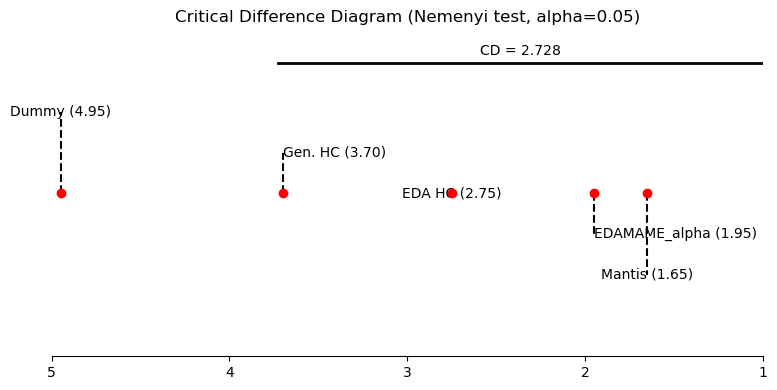

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, rankdata, studentized_range
import matplotlib.pyplot as plt

# =========================
# 1. Dataset Initialization
# =========================
methods = ["Dummy", "Gen. HC", "EDA HC", "EDAMAME_alpha", "Mantis"]

tacv = np.array(
    [
        [0.43, 0.80, 0.80, 0.89, 0.86],  # APSYNC
        [0.48, 0.55, 0.59, 0.63, 0.64],  # Dreamt
        [0.50, 0.65, 0.69, 0.70, 0.73],  # Dreamt
        [0.51, 0.66, 0.72, 0.73, 0.75],  # HeartS
        [0.49, 0.55, 0.54, 0.63, 0.61],  # WESAD
    ],
    dtype=float,
)

lopo = np.array(
    [
        [0.48, 0.70, 0.74, 0.75, 0.76],  # Dreamt
        [0.50, 0.66, 0.70, 0.71, 0.72],  # USILaughs
        [0.50, 0.66, 0.70, 0.72, 0.74],  # HeartS
        [0.56, 0.61, 0.63, 0.61, 0.56],  # WESAD
        [0.50, 0.56, 0.64, 0.60, 0.63],  # HHISS
    ],
    dtype=float,
)

# Combine datasets (N = 10 datasets, k = 5 methods)
combined = np.vstack((tacv, lopo))
N, k = combined.shape

# =========================
# 2. Friedman Test
# =========================
stat, p_friedman = friedmanchisquare(*(combined.T))
print(f"Friedman Test: Statistic = {stat:.3f}, p-value = {p_friedman:.5f}")

# =========================
# 3. Average Ranks
# =========================
# Negate data so the highest performance gets rank 1
ranks = np.array([rankdata(-row) for row in combined])
avg_ranks = np.mean(ranks, axis=0)

print("\nAverage Ranks:")
for m, r in zip(methods, avg_ranks):
    print(f"{m}: {r:.2f}")

# =========================
# 4. Nemenyi Post-Hoc Test
# =========================
# Calculate the Nemenyi denominator for the Critical Difference (CD)
denom = np.sqrt((k * (k + 1)) / (6 * N))

# q_alpha for k=5, alpha=0.05 is approx 2.728 (from Demšar, 2006)
q_alpha = studentized_range.ppf(1 - 0.05, k, np.inf) 
CD = q_alpha * denom
print(f"\nCritical Difference (CD) at alpha=0.05: {CD:.3f}")

# =========================
# 5. P-Value Calculations for EDAMAME_alpha
# =========================
print("\np-values for EDAMAME_alpha vs others:")
ours_idx = methods.index("EDAMAME_alpha")

for other_method in ["Mantis", "Gen. HC", "EDA HC"]:
    other_idx = methods.index(other_method)
    
    # Calculate difference in average ranks
    diff = np.abs(avg_ranks[ours_idx] - avg_ranks[other_idx])
    
    # Calculate the q-statistic
    q_stat = diff / denom
    
    # Calculate the p-value using the Studentized range distribution (survival function)
    p_val = studentized_range.sf(q_stat, k, np.inf)
    print(f"vs {other_method}: Diff = {diff:.2f}, q = {q_stat:.3f}, p = {p_val:.4f}")

# =========================
# 6. Critical Difference Plot
# =========================
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_title("Critical Difference Diagram (Nemenyi test, alpha=0.05)")

# Sort methods by rank for plotting
sorted_indices = np.argsort(avg_ranks)
sorted_methods = [methods[i] for i in sorted_indices]
sorted_ranks = avg_ranks[sorted_indices]

# Set up axes
ax.set_xlim(1, k)
ax.set_ylim(-1, 1)
ax.set_yticks([])
ax.set_xticks(range(1, k+1))
ax.invert_xaxis()  # Rank 1 on the right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Plot CD indicator bar
ax.plot([1, 1 + CD], [0.8, 0.8], color='k', lw=2)
ax.text(1 + CD/2, 0.85, f"CD = {CD:.3f}", ha='center')

# Plot methods
y_pos = np.linspace(-0.5, 0.5, k)
for i, (m, r) in enumerate(zip(sorted_methods, sorted_ranks)):
    ax.scatter(r, 0, color='r', zorder=5)
    ax.vlines(r, 0, y_pos[i], color='k', linestyles='--')
    ax.text(r, y_pos[i], f"{m} ({r:.2f})", ha='center' if i % 2 == 0 else 'left', va='center', fontsize=10)

plt.tight_layout()
plt.show()